In [1]:
from omegaconf import DictConfig
import hydra
import rootutils
rootutils.setup_root(search_from=".", indicator='setup.py', pythonpath=True)

PosixPath('/work/hpc/spine-segmentation')

In [19]:
torch.load("/work/hpc/spine-segmentation/logs/train/runs/2024-08-13_12-07-08/checkpoints/epoch_097.ckpt")

NameError: name 'torch' is not defined

In [3]:
with hydra.initialize(version_base="1.3", config_path="../configs", ):
    cfg = hydra.compose(config_name='train.yaml')
    print(cfg)

{'task_name': 'train', 'tags': ['dev'], 'train': True, 'test': True, 'ckpt_path': None, 'seed': None, 'data': {'transform_train': {'_target_': 'monai.transforms.Compose', 'transforms': [{'_target_': 'monai.transforms.LoadImaged', 'keys': ['image', 'label']}, {'_target_': 'src.data.transforms.array.ConvertToMultiChannelBasedOnSpiderClassesdSemantic', 'keys': 'label', 'include_background': '${data.include_background}'}, {'_target_': 'monai.transforms.EnsureChannelFirstd', 'keys': 'image'}, {'_target_': 'monai.transforms.Spacingd', 'keys': ['image', 'label'], 'pixdim': [1.7, 0.625, 0.58742571], 'mode': [3, 'nearest']}, {'_target_': 'monai.transforms.RandAffined', 'keys': ['image', 'label'], 'prob': 0.15, 'rotate_range': [[-0.1, 0.1], [-0.3, 0.3], [-0.3, 0.3]], 'scale_range': [[-0.05, 0.05], [-0.08, 0.08], [-0.05, 0.05]], 'padding_mode': 'zeros', 'mode': [3, 'nearest']}, {'_target_': 'monai.transforms.RandSpatialCropd', 'keys': ['image', 'label'], 'roi_size': [32, 288, 288], 'random_size':

In [4]:
datamodule = hydra.utils.instantiate(cfg.data)

Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.


In [8]:
datamodule.setup()

In [9]:
train_loader = datamodule.train_dataloader()

In [10]:
iterator = iter(train_loader)

In [11]:
batch = next(iterator)
print(batch.keys())

dict_keys(['image', 'label'])


In [11]:
batch['border']

['/work/hpc/spine-segmentation/data//dataset/spine_nii/border/40_t1.nii.gz',
 '/work/hpc/spine-segmentation/data//dataset/spine_nii/border/81_t2_SPACE.nii.gz']

In [12]:
labels = batch['label'].detach().cpu().numpy().copy()

In [13]:
labels.shape

(4, 3, 32, 288, 288)

In [15]:
import matplotlib.pyplot as plt

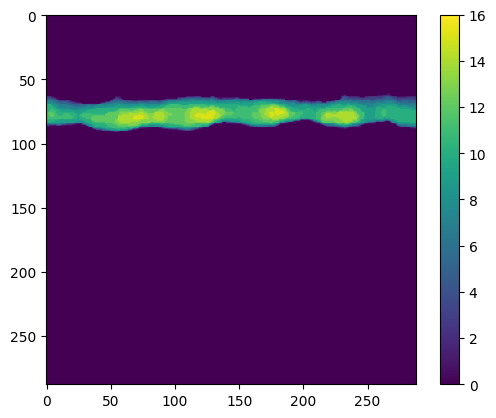

In [18]:
img = plt.imshow(np.sum(labels[1, 1], axis=0))
cbar = plt.colorbar(img)
plt.show()

In [ ]:
values= np.unique(labels[1])

In [ ]:
print(values)

In [ ]:
labels[labels < 0.5] = 0

In [ ]:
import plotly.graph_objects as go 

In [ ]:
pcd = np.stack(np.where(labels[1, 2] == 1)).T 

In [ ]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=pcd[:, 0], y=pcd[:, 1], z=pcd[:, 2],
            mode='markers',
            marker=dict(size=1, color=(1, 0, 0)),

        )
    ],
    layout = dict(title=dict(text="Normalized and Reduced Mask Point Cloud"))
)
fig.show()

In [9]:
cfg.data

{'transform_train': {'_target_': 'monai.transforms.Compose', 'transforms': [{'_target_': 'monai.transforms.LoadImaged', 'keys': ['image', 'label']}, {'_target_': 'src.data.transforms.array.ConvertToMultiChannelBasedOnSpiderClassesdSemantic', 'keys': 'label', 'include_background': '${data.include_background}'}, {'_target_': 'monai.transforms.EnsureChannelFirstd', 'keys': 'image'}, {'_target_': 'monai.transforms.Spacingd', 'keys': ['image', 'label'], 'pixdim': [1.7, 0.625, 0.58742571], 'mode': [3, 'nearest']}, {'_target_': 'monai.transforms.RandAffined', 'keys': ['image', 'label'], 'prob': 0.15, 'rotate_range': [[-0.1, 0.1], [-0.3, 0.3], [-0.3, 0.3]], 'scale_range': [[-0.05, 0.05], [-0.08, 0.08], [-0.05, 0.05]], 'padding_mode': 'zeros', 'mode': [3, 'nearest']}, {'_target_': 'monai.transforms.RandSpatialCropd', 'keys': ['image', 'label'], 'roi_size': [32, 288, 288], 'random_size': False}, {'_target_': 'monai.transforms.RandFlipd', 'keys': ['image', 'label'], 'prob': 0.5, 'spatial_axis': 0